<a href="https://colab.research.google.com/github/adityaprasad2005/ES335-assignment_2/blob/main/Task4_2_image_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 4.2 ** Consider a case where 900 pixels (30x30) are randomly missing from an image. Reconstruct the image using matrix factorization, plot the reconstructed image, and calculate the RMSE and PSNR metrics. Next, reconstruct the same image with the missing pixels using Random Fourier Features (RFF) and Linear Regression. Compare the performance of all the three methodologies.

**Image Reconstruction using WH low-rank iterative matrix factorization**

In [ ]:

#import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Set device to cuda:0 if available and on Linux
# If on mac try mps
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Working on device: ", device)


# define the func for the iterative low-rank WH decomposition
def factorize_matrix(A, r, device= torch.device("cpu")):
  """
  Inputs
  A: ratings matrix of shape(n_user, n_movies)
  r: number of latent features

  Outputs
  W: matrix of shape(n_user, r)
  H: matrix of shape(r, n_movies)
  loss: loss value
  """
  n_user, n_movies = A.shape

  A = A.to(device)
  W = torch.randn(n_user, r, requires_grad= True, device = device)
  H = torch.randn(r, n_movies, requires_grad= True, device = device)

  optimizer = optim.Adam([W,H], lr= 0.01)

  mask = ~torch.isnan(A)

  for i in range(1000):
    diff_matrix = A - torch.mm(W, H)
    diff_matrix = diff_matrix[mask]

    loss = torch.norm(diff_matrix)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  return W, H, loss


Working on device:  cpu


In [ ]:
# Download the image
import os
if os.path.exists('dog.jpg'):
    print('dog.jpg exists')
else:
    !wget https://segment-anything.com/assets/gallery/AdobeStock_94274587_welsh_corgi_pembroke_CD.jpg -O dog.jpg

dog.jpg exists


In [ ]:
#Read the image using torchvision
import torchvision

image = torchvision.io.read_image('dog.jpg')
print(image.shape)

torch.Size([3, 1365, 2048])


In [ ]:
#turn the image into grayscale
image = torch.tensor(image, dtype = torch.float)
image = image.mean(dim= 0, keepdim= False)
image.shape

<ipython-input-22-c31addf68774>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype = torch.float)


torch.Size([1365, 2048])

torch.Size([300, 300])


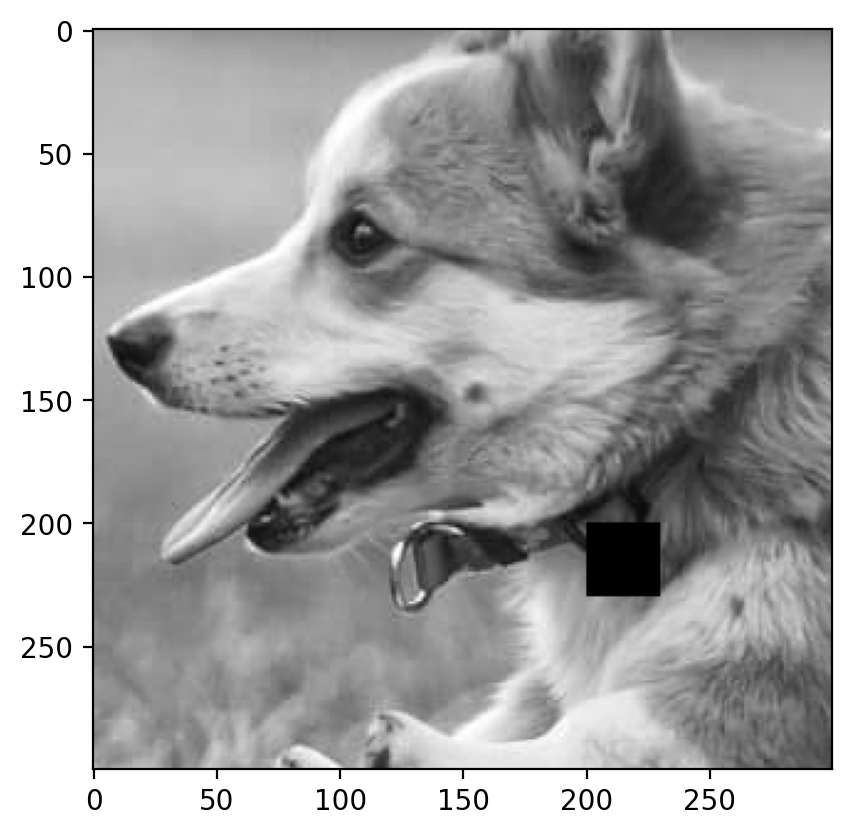

In [ ]:
#crop this image
# plt.imshow(image, cmap= 'gray')
cropped_img = torchvision.transforms.functional.crop(image, 600, 800, 300, 300)
print(cropped_img.shape)

#set a image patch(30x30) to zero
cropped_img[200:230, 200:230] = 0

plt.imshow(cropped_img, cmap= 'gray')


r: 50 loss: 1688.462890625


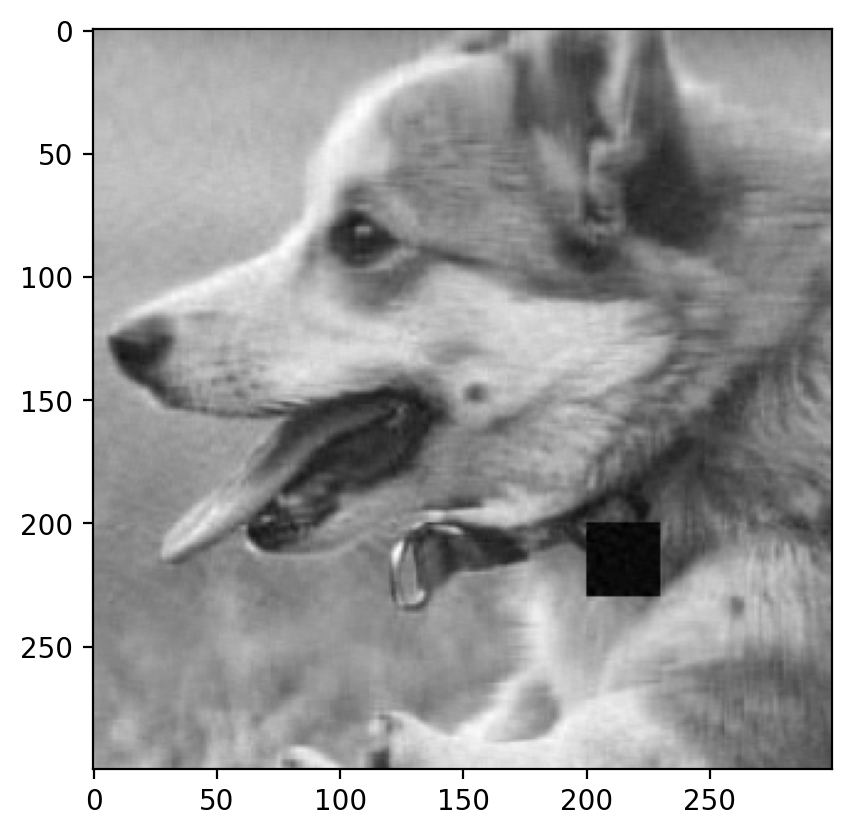

In [ ]:
#factorize the image and show the reconstructed image
W, H, loss = factorize_matrix(cropped_img, 50, device)
reconstructed_img = torch.mm(W, H)
plt.imshow(reconstructed_img.cpu().detach().numpy(), cmap= 'gray')
print(f"r: 50 loss: {loss}")

**Image Reconstruction using Random Fourier Features**

**Image Reconstruction using Linear Regression**

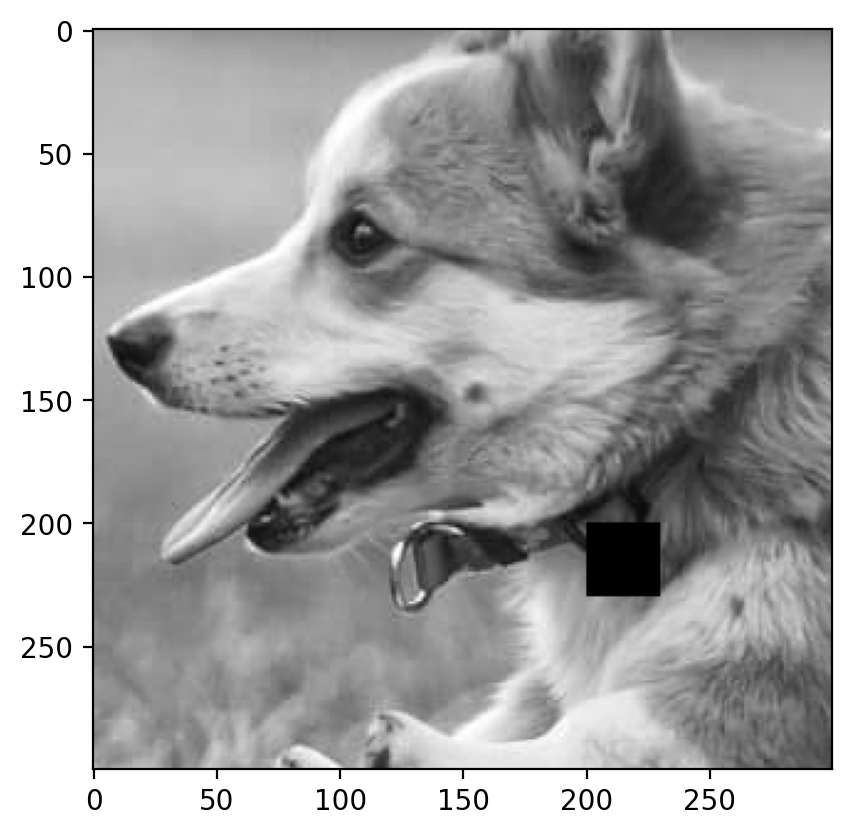

In [ ]:
plt.imshow(cropped_img, cmap= 'gray')

In [ ]:
def get_coordinate_map(A):
  """
  Inputs:
  A: matrix torch.Tensor of shape(n_rows, n_cols)
  Outputs:
  X: coordinate matrix containing the coordinates x, y in 2 columns
  y: gray scale values
  """

  n_rows, n_cols = A.shape

  cmap = torch.meshgrid(torch.arange(n_cols), torch.arange(n_rows), indexing= 'ij')




NameError: name 'A' is not defined